<a href="https://colab.research.google.com/github/Dexter0013/Deepraj-Singha-6th-Sem-CSE-Data-Mining-Assignments/blob/main/3.%20KNN%20on%20IRIS%20Dataset/KNN%20on%20IRIS%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (120, 4)
Testing set shape: (30, 4)


### K-Nearest Neighbors Model

In [9]:
# Updating the KNN model with the optimal k value found from the graph
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

print("KNN Training Complete with k=3.")

KNN Training Complete with k=3.


### Final Model Evaluation and Confusion Matrix

Test Accuracy: 1.0000

KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



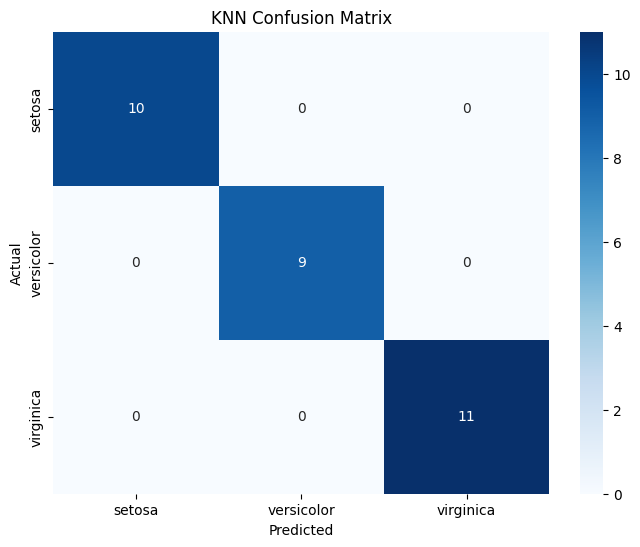

In [10]:
# Predict using the KNN
y_pred = knn.predict(X_test_scaled)

# Accuracy
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

# Classification Report
print("KNN Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
import numpy as np
# Predict for a single new flower
# [SepalLength, SepalWidth, PetalLength, PetalWidth]
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
# Scale the new flower data using the fitted scaler
new_flower_scaled = scaler.transform(new_flower)
prediction = knn.predict(new_flower_scaled)
print(f"Predicted Species: {iris.target_names[prediction][0]}")

Predicted Species: setosa
